<h1  style="color:#000000; text-align:center; font-weight:bold;">DATASCI 530 Assignment 4</h1>
<h1  style="color:#000000; text-align:center; font-weight:bold;">Bills Actions from the 116th Congress of the United States</h1>
<p  style="color:#000000; text-align:center; font-size:18px;">Maxine Hakimi-Bulson</p>

<h2 style="color:#000000;">Bills actions from the 116th Congress of the United States</h2>

write a couple sentences about Topic here. In this dataset are 1331 bills from the 166th Congress.

<h2 style="color:#000000;">Summary of Findings</h2>

write summary of findings here

<h2 style="color:#000000;">Loading Libraries and Data</h2>

First we will load the necessary libraries and data to complete our analyses.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bills_actions = pd.read_csv("data/bills_actions.csv")

<h2 style="color:#000000;">Inquiry & Analysis</h2>

<h3 style="color:#000000;"> Basic  Descriptive  Statistics  </h3>

- How  many  distinct  “bill” identifiers  are  there?  

- What  proportion  of  rows  belongs  to  each  category?  

- What proportion belongs to different “main_action”?


 I counted distinct combinations of bill type and bill number to account for different bill types sharing the same number. While Data Wrangler provides summary statistics, the category summaries only display the top 3 values and percentages, and the rest are listed as "Other." This is an issue since `main_action` lists 31% of its data under "Other," so I calculated the counts and proportions for every category.

In [11]:
# Count distinct bill identifiers
identifier_counts = bills_actions.groupby(
    ["bill_type", "bill_number"]).size()
number_identifiers = len(identifier_counts)
#print(number_identifiers)

# counts and proportions of all action rows
table_category = pd.DataFrame({
    "Number of rows": bills_actions["category"].value_counts()})
table_category["Proportion"] = (table_category["Number of rows"] / len(bills_actions))

# main-action counts and proportions of all action rows
table_main_action = pd.DataFrame({
    "Number of rows": bills_actions["main_action"].value_counts()})
table_main_action["Proportion"] = (table_main_action["Number of rows"] / len(bills_actions))

# display results side by side
from IPython.display import display, HTML

category_html = (
    table_category.style
    .format({
        "Number of rows": "{:,.0f}",
        "Proportion": "{:.1%}"
    })
    .set_caption("Action rows by category")
    .to_html())

main_action_html = (
    table_main_action.style
    .format({
        "Number of rows": "{:,.0f}",
        "Proportion": "{:.1%}"
    })
    .set_caption("Action rows by main action")
    .to_html())

display(HTML(
    '<div style="display:flex; gap:30px; align-items:flex-start;">'
    '<div>' + category_html + '</div>'
    '<div>' + main_action_html + '</div>'
    '</div>'))

# quality checks: both proportions should sum to approximately 1
#print(table_category["Proportion"].sum())
#print(table_main_action["Proportion"].sum())

,Number of rows,Proportion
category,,
amendment,"1,529",46.3%
house bill,902,27.3%
senate bill,514,15.6%
house resolution,234,7.1%
senate resolution,60,1.8%
house joint resolution,22,0.7%
house concurrent resolution,20,0.6%
senate concurrent resolution,14,0.4%
senate joint resolution,8,0.2%


There are 1,494 distinct bill identifiers. Amendments account for almost half of the action rows (46.3%), followed by House (27.3%) and Senate bills (15.6%). House floor actions (30.9%) and House amendments offered (25.1%) are the most common main actions, together representing over half of the rows.

<h3 style="color:#000000;"> House Floor Actions Associated with Bills in the “Senate bills” Category  </h3>

- What proportion of these actions were suspended? What proportion of these 
actions were suspended as amended?

- The  House  floor  actions  mention  specific  people  by  (Mr.,  Ms.,  Mrs.,  etc).  Use 
regular  expressions  to  extract  the  names  of  specific  people.  Produce  a  new 
dataset counting how many bills mention the same person and then extract the 
unique list of names of the people mentioned. What is the distribution of total 
bills proposed per person?

explain methods here

Action description,Number of actions,Proportion
Mentions suspension of the rules,80,69.0%
Mentions suspension and passage as amended,18,15.5%


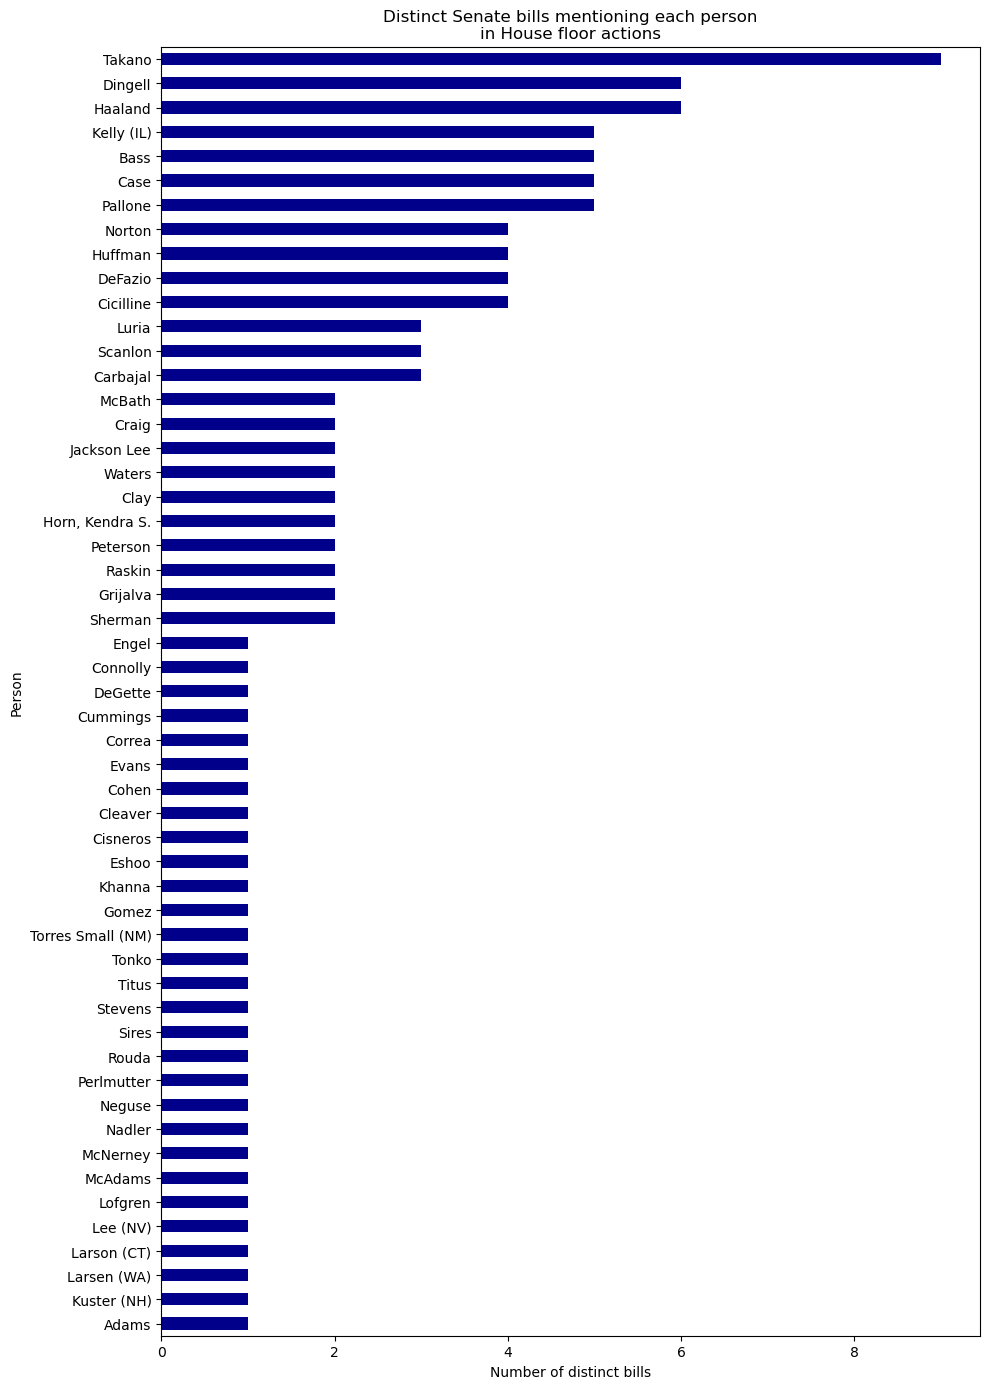

In [28]:
# Select House floor actions associated with Senate bills
senate_bills_house_floor = bills_actions.query(
    'category == "senate bill" & main_action == "house floor actions"')
number_actions = len(senate_bills_house_floor)
#print(number_actions)

# Identify suspension mentions, including those specifying "as amended"
suspension = senate_bills_house_floor["action"].str.contains("suspend the rules")
suspension_amended = (suspension & senate_bills_house_floor["action"].str.contains("as amended"))

table_suspension = pd.DataFrame({
    "Action description": [
        "Mentions suspension of the rules",
        "Mentions suspension and passage as amended"],
    "Number of actions": [suspension.sum(), suspension_amended.sum()],
    "Proportion": [suspension.mean(), suspension_amended.mean()]})

display(
    table_suspension.style
    .format({
        "Number of actions": "{:,.0f}",
        "Proportion": "{:.1%}"
    })
    .hide(axis="index")
    .set_caption("Suspension mentions in House floor actions on Senate bills"))

# Extract names and attach them to bill identifiers
name_matches = senate_bills_house_floor["action"].str.findall(
    r"(?:Mr|Ms|Mrs)\. (.*?) (?:asked|moved)")

people_bills = senate_bills_house_floor[
    ["bill_type", "bill_number"]].copy()
people_bills["Person"] = name_matches.apply(lambda names: names[0])

# Count each distinct bill once per person
person_bill_counts = (
    people_bills.groupby(["Person", "bill_type", "bill_number"])
    .size()
    .reset_index(name="Number of actions"))

table_people = (
    person_bill_counts.groupby("Person")
    .size()
    .reset_index(name="Number of distinct bills"))

unique_people = table_people["Person"].unique()

# Plot bill counts for all people
people_plot = table_people.sort_values(
    "Number of distinct bills", ascending=True)

people_plot.plot(
    x="Person",
    y="Number of distinct bills",
    kind="barh",
    color="darkblue",
    figsize=(10, 14),
    legend=False)
plt.xlabel("Number of distinct bills")
plt.ylabel("Person")
plt.title("Distinct Senate bills mentioning each person\nin House floor actions")
plt.tight_layout()
plt.show()

# Quality checks
#print(name_matches.apply(len).value_counts())
#print(len(unique_people))
#print(unique_people)

There are 116 house floor actions associated with Senate bills. 69% of those mention a motion to suspend the rules, and 15.5% motion to suspend as amended.

<h3 style="color:#000000;"> 3. Now  focus  on  a  subset  of  bills  whose  actions  are  marked  as  “Senate  amendment proposed (on the floor)”. An important feature of the text is that it can mention one or 
more senators. </h3>

- Produce a new dataset counting how many senators are mentioned per bill. This 
dataset  should  also  include  two  variables,  with  the  name  of  the  first  senator 
(Senator 1) mentioned in the bill and the name of the second senator (Senator 2). What is the distribution of the number of senators per bill? 

- With how many different people does each Senator coauthor bills, i.e. how many 
different people appear as Senator 2 for each Senator 1?

explain methods here

explain

<h3 style="color:#000000;"> Insights </h3>

explain methods here

explain

<h2 style="color:#000000;">New Insights</h2>

<h3 style="color:#000000;"> 5. Compute an additional table or figure not included in the questions above.  </h3>

explain methods here

<h3 style="color:#000000;"> 6. What do we learn from this new table or figure?  </h3>

answer here